# Instalación de librerías y Configuración

In [1]:
!pip install kagglehub nibabel torch torchvision matplotlib

import os
import tarfile
import shutil
import kagglehub
import time
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo actual: {device}")

Dispositivo actual: cuda


# Descarga y Preparación del Dataset

In [2]:
# Descarga y Extracción
print("Descargando el dataset...")
base_path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")
extract_path = "/kaggle/working/brats_data"
clean_path = "/kaggle/working/brats_clean"

os.makedirs(extract_path, exist_ok=True)
os.makedirs(clean_path, exist_ok=True)

# Extraemos tars
for file in os.listdir(base_path):
    if file.endswith(".tar"):
        tar_path = os.path.join(base_path, file)
        print(f"Extrayendo {file}...")
        with tarfile.open(tar_path) as tar:
            tar.extractall(path=extract_path)

# Movemos carpetas a un directorio limpio
for folder in os.listdir(extract_path):
    folder_path = os.path.join(extract_path, folder)
    if os.path.isdir(folder_path):
        dst = os.path.join(clean_path, folder)
        if not os.path.exists(dst):
            shutil.move(folder_path, dst)

print("Estructura de carpetas lista")

Descargando el dataset...
Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Extrayendo BraTS2021_00495.tar...
Extrayendo BraTS2021_Training_Data.tar...


/tmp/ipykernel_849/399646640.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extrayendo BraTS2021_00621.tar...
Estructura de carpetas lista


# Split del Dataset (Train / Val / Test)

In [3]:
# División de datos (Split 70% Train, 10% Val, 20% Test)
patients = sorted([
    os.path.join(clean_path, p)
    for p in os.listdir(clean_path)
    if os.path.isdir(os.path.join(clean_path, p))
])

n_patients = len(patients)

# 70% para Train
train_split = int(0.7 * n_patients)
# El siguiente 10% para Val (llegando al 80% del total)
val_split = int(0.8 * n_patients)

train_patients = patients[:train_split]
val_patients = patients[train_split:val_split]
test_patients = patients[val_split:]

print(f"Total pacientes: {n_patients}")
print(f"Train: {len(train_patients)} | Val: {len(val_patients)} | Test: {len(test_patients)}")

Total pacientes: 1251
Train: 875 | Val: 125 | Test: 251


# PyTorch Dataset Nativo (Adaptación 3D y 4 Canales)

In [4]:
# Custom PyTorch Dataset
class BraTS3DDataset(Dataset):
    def __init__(self, patient_dirs, crop_size=(64, 64, 64), is_train=True):
        self.patient_dirs = patient_dirs
        self.crop_size = crop_size
        self.is_train = is_train

    def __len__(self):
        return len(self.patient_dirs)

    def __getitem__(self, idx):
        p_dir = self.patient_dirs[idx]
        pid = os.path.basename(p_dir)

        # Cargamos las 4 modalidades
        t1 = nib.load(os.path.join(p_dir, f"{pid}_t1.nii.gz")).get_fdata()
        t1ce = nib.load(os.path.join(p_dir, f"{pid}_t1ce.nii.gz")).get_fdata()
        t2 = nib.load(os.path.join(p_dir, f"{pid}_t2.nii.gz")).get_fdata()
        flair = nib.load(os.path.join(p_dir, f"{pid}_flair.nii.gz")).get_fdata()
        seg = nib.load(os.path.join(p_dir, f"{pid}_seg.nii.gz")).get_fdata()

        # Apilamos para crear el tensor (Canales, Profundidad, Alto, Ancho)
        x = np.stack([t1, t1ce, t2, flair], axis=0).astype(np.float32)

        # Máscara binaria (cualquier tejido tumoral > 0 será 1)
        y = (seg > 0).astype(np.float32)[np.newaxis, ...]

        # Normalización Z-score por canal
        for c in range(4):
            mean, std = np.mean(x[c]), np.std(x[c])
            if std > 0:
                x[c] = (x[c] - mean) / std

        # Cropping volumétrico para evitar OOM (Out Of Memory) en Colab
        _, D, H, W = x.shape
        cD, cH, cW = self.crop_size

        if self.is_train:
            start_d = np.random.randint(0, D - cD) if D > cD else 0
            start_h = np.random.randint(0, H - cH) if H > cH else 0
            start_w = np.random.randint(0, W - cW) if W > cW else 0
        else: # Center crop para Val/Test
            start_d = max((D - cD) // 2, 0)
            start_h = max((H - cH) // 2, 0)
            start_w = max((W - cW) // 2, 0)

        x_crop = x[:, start_d:start_d+cD, start_h:start_h+cH, start_w:start_w+cW]
        y_crop = y[:, start_d:start_d+cD, start_h:start_h+cH, start_w:start_w+cW]

        return torch.tensor(x_crop), torch.tensor(y_crop)

# Instanciamos Datasets y DataLoaders
train_ds = BraTS3DDataset(train_patients, is_train=True)
val_ds = BraTS3DDataset(val_patients, is_train=False)
test_ds = BraTS3DDataset(test_patients, is_train=False)

# Aceleramos la carga de datos usando múltiples procesos y memoria fijada
train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,           # Usa 2 núcleos de CPU en paralelo
    pin_memory=True,         # Acelera la transferencia CPU -> GPU
    persistent_workers=True  # Mantiene los procesos vivos entre épocas
)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# Arquitectura U-Net 3D Pura de PyTorch

In [5]:
# U-Net 3D
class DoubleConv3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv3D(in_channels, 16)
        self.pool1 = nn.MaxPool3d(2)
        self.down2 = DoubleConv3D(16, 32)
        self.pool2 = nn.MaxPool3d(2)
        self.down3 = DoubleConv3D(32, 64)
        self.pool3 = nn.MaxPool3d(2)

        # Cuello de botella
        self.bottleneck = DoubleConv3D(64, 128)

        # Decoder
        self.up3 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv3D(128, 64)
        self.up2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.conv2 = DoubleConv3D(64, 32)
        self.up1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.conv1 = DoubleConv3D(32, 16)

        # Salida
        self.out = nn.Conv3d(16, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))

        b = self.bottleneck(self.pool3(x3))

        u3 = self.conv3(torch.cat([self.up3(b), x3], dim=1))
        u2 = self.conv2(torch.cat([self.up2(u3), x2], dim=1))
        u1 = self.conv1(torch.cat([self.up1(u2), x1], dim=1))

        return self.out(u1)

model = UNet3D().to(device)

# Función de Pérdida (Dice Loss) y Optimizador

In [6]:
# Loss Combinada (Dice + BCE) y Optimizador

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        # PyTorch ya tiene la función BCE optimizada
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # Calculamos el BCE (que evalúa vóxel a vóxel estíctamente)
        bce_loss = self.bce(logits, targets)

        # Calculamos el Dice (que evalúa el solapamiento de la masa)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3, 4))
        union = probs.sum(dim=(2, 3, 4)) + targets.sum(dim=(2, 3, 4))
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice_score.mean()

        # Devolvemos la suma de ambas
        return bce_loss + dice_loss

# Inicializamos el Loss y el Optimizador
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Bucle de Entrenamiento y Validación

In [7]:
# Entrenamiento (Acumulación de Gradientes + DiceBCE)

epochs = 10
accumulation_steps = 4  # Simula un batch_size de 4 para dar estabilidad

scaler = torch.amp.GradScaler('cuda')

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss = 0.0

    # Reseteamos los gradientes al inicio de la época
    optimizer.zero_grad()

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # Dividimos la loss entre 4 para promediarla
            loss = loss / accumulation_steps

        # Escalamos y acumulamos el gradiente en la memoria
        scaler.scale(loss).backward()

        # Cada 4 pacientes (o al final del dataset), aplicamos los cambios a la red
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad() # Reseteamos para el siguiente bloque de 4

        # Para el print visual, multiplicamos por 4 para ver el error real
        train_loss += (loss.item() * accumulation_steps)

    avg_train_loss = train_loss / len(train_loader)

    # Fase de Validación (Aquí evaluamos normal, sin acumular)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Tiempo: {epoch_time:.0f}s")

Epoch 1/10 | Train Loss: 1.4116 | Val Loss: 1.6173 | Tiempo: 620s
Epoch 2/10 | Train Loss: 1.3080 | Val Loss: 1.1995 | Tiempo: 609s
Epoch 3/10 | Train Loss: 1.2504 | Val Loss: 1.1720 | Tiempo: 612s
Epoch 4/10 | Train Loss: 1.1877 | Val Loss: 1.2467 | Tiempo: 607s
Epoch 5/10 | Train Loss: 1.1404 | Val Loss: 1.1509 | Tiempo: 605s
Epoch 6/10 | Train Loss: 1.0803 | Val Loss: 1.3314 | Tiempo: 605s
Epoch 7/10 | Train Loss: 1.0525 | Val Loss: 1.9778 | Tiempo: 597s
Epoch 8/10 | Train Loss: 1.0151 | Val Loss: 1.7218 | Tiempo: 596s
Epoch 9/10 | Train Loss: 0.9867 | Val Loss: 1.1395 | Tiempo: 604s
Epoch 10/10 | Train Loss: 0.9501 | Val Loss: 1.2615 | Tiempo: 610s


# Fase de Inferencia (Test) y Visualización superpuesta

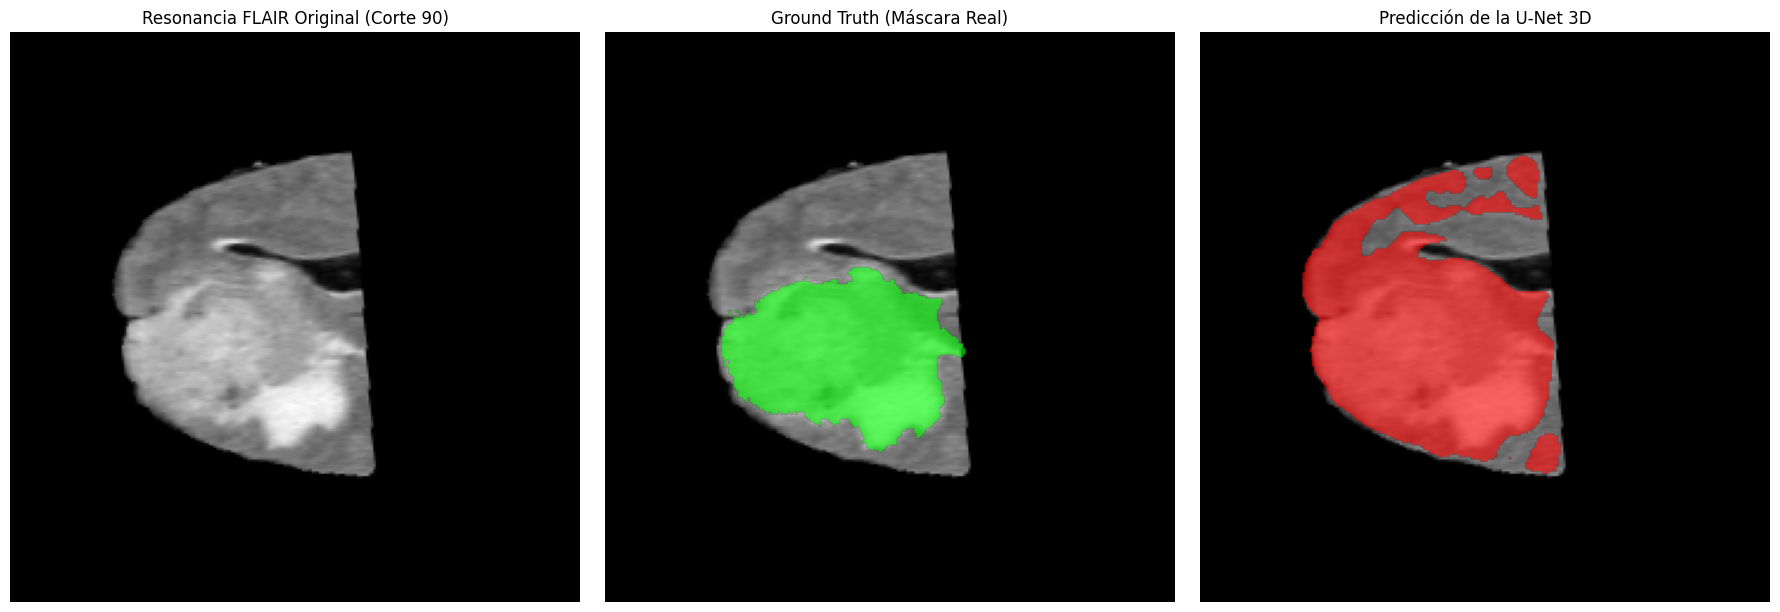

In [8]:
# Inferencia sobre el volumen original completo (Colores Vivos)

model.eval()

# Tomamos el primer paciente de la lista de test
p_dir = test_patients[0]
pid = os.path.basename(p_dir)

# Cargamos las imágenes completas originales (dimensiones: 240, 240, 155)
t1 = nib.load(os.path.join(p_dir, f"{pid}_t1.nii.gz")).get_fdata()
t1ce = nib.load(os.path.join(p_dir, f"{pid}_t1ce.nii.gz")).get_fdata()
t2 = nib.load(os.path.join(p_dir, f"{pid}_t2.nii.gz")).get_fdata()
flair = nib.load(os.path.join(p_dir, f"{pid}_flair.nii.gz")).get_fdata()
seg = nib.load(os.path.join(p_dir, f"{pid}_seg.nii.gz")).get_fdata()

# Apilamos y normalizamos
x = np.stack([t1, t1ce, t2, flair], axis=0).astype(np.float32)
y_true = (seg > 0).astype(np.float32) # Máscara original

for c in range(4):
    mean, std = np.mean(x[c]), np.std(x[c])
    if std > 0:
        x[c] = (x[c] - mean) / std

x_tensor = torch.tensor(x).unsqueeze(0).to(device)

# PADDING: Añadimos 5 a la última dimensión (155 -> 160)
x_padded = F.pad(x_tensor, (0, 5, 0, 0, 0, 0))

# Hacemos la predicción sobre el cerebro completo
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        raw_pred = model(x_padded)
        probs = torch.sigmoid(raw_pred)
        pred_mask_padded = (probs > 0.5).float().cpu().numpy()[0, 0]

# Quitamos el padding de la ÚLTIMA dimensión para volver a 155
pred_mask = pred_mask_padded[:, :, :-5]

# Buscamos el corte en Z donde el tumor es más grande
slice_idx = np.argmax(y_true.sum(axis=(0, 1)))


# CREACIÓN DE COLORES PUROS
# Forzamos un rojo puro y un verde brillante
cmap_real = ListedColormap(['lime']) # Verde neón
cmap_pred = ListedColormap(['red'])  # Rojo vivo


# Visualización
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title(f"Resonancia FLAIR Original (Corte {slice_idx})")
plt.imshow(flair[:, :, slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Máscara Real)")
plt.imshow(flair[:, :, slice_idx], cmap="gray")
# Máscara Real en Verde neón
true_mask_vis = np.ma.masked_where(y_true[:, :, slice_idx] == 0, y_true[:, :, slice_idx])
plt.imshow(true_mask_vis, cmap=cmap_real, alpha=0.6)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predicción de la U-Net 3D")
plt.imshow(flair[:, :, slice_idx], cmap="gray")
# Predicción en Rojo puro
pred_mask_vis = np.ma.masked_where(pred_mask[:, :, slice_idx] == 0, pred_mask[:, :, slice_idx])
plt.imshow(pred_mask_vis, cmap=cmap_pred, alpha=0.6)
plt.axis("off")

plt.tight_layout()
plt.show()